In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '3848',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.8',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '64',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

setpoint = [1.0, 0.0]

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample), setpoint, load_normalized=True)

training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.254825, valid=0.241295, test=0.241348
	validation loss decreased (inf -> 0.241295), saving model ...
	epoch 2 losses: train=0.226569, valid=0.153414, test=0.151082
	validation loss decreased (0.241295 -> 0.153414), saving model ...
	epoch 3 losses: train=0.078042, valid=0.008833, test=0.008781
	validation loss decreased (0.153414 -> 0.008833), saving model ...
	epoch 4 losses: train=0.002901, valid=0.000926, test=0.000934
	validation loss decreased (0.008833 -> 0.000926), saving model ...
	epoch 5 losses: train=0.000537, valid=0.000289, test=0.000287
	validation loss decreased (0.000926 -> 0.000289), saving model ...
	epoch 6 losses: train=0.000210, valid=0.000139, test=0.000137
	validation loss decreased (0.000289 -> 0.000139), saving model ...
	epoch 7 losses: train=0.000104, valid=0.000077, test=0.000076
	validation loss decreased (0.000139 -> 0.000077), saving model ...
	epoch 8 losses: train=0.000064, valid=0.000056, test=0.00

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

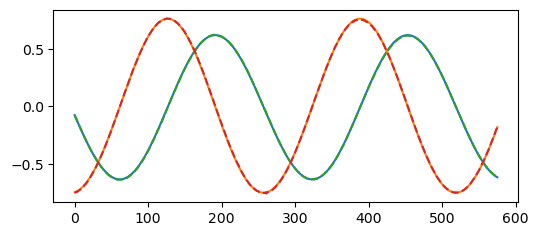

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break


In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.087149, valid=0.032837, test=0.032187
	validation loss decreased (inf -> 0.032837), saving model ...
	epoch 2 losses: train=0.029160, valid=0.027629, test=0.027108
	validation loss decreased (0.032837 -> 0.027629), saving model ...
	epoch 3 losses: train=0.024239, valid=0.023544, test=0.023271
	validation loss decreased (0.027629 -> 0.023544), saving model ...
	epoch 4 losses: train=0.023451, valid=0.023389, test=0.023055
	validation loss decreased (0.023544 -> 0.023389), saving model ...
	epoch 5 losses: train=0.023323, valid=0.023087, test=0.022851
	validation loss decreased (0.023389 -> 0.023087), saving model ...
	epoch 6 losses: train=0.022821, valid=0.021684, test=0.021480
	validation loss decreased (0.023087 -> 0.021684), saving model ...
	epoch 7 losses: train=0.021290, valid=0.020377, test=0.020401
	validation loss decreased (0.021684 -> 0.020377), saving model ...
	epoch 8 losses: train=0.020441, valid=0.020361, te

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

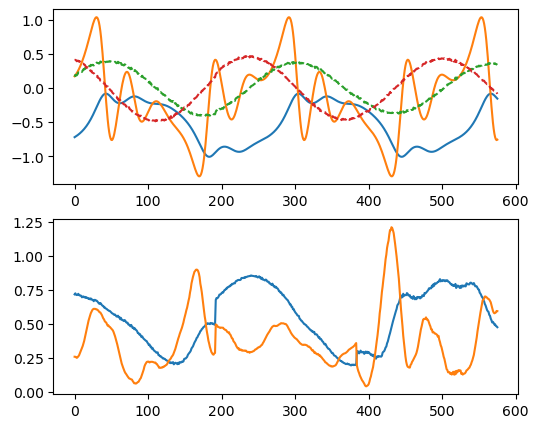

In [9]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_u = model_output[2]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(stat_u[0, :, :2])

        plt.show()

        break


In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.282855, valid=0.188757, test=0.189509
	validation loss decreased (inf -> 0.188757), saving model ...
	epoch 2 losses: train=0.182488, valid=0.173700, test=0.172879
	validation loss decreased (0.188757 -> 0.173700), saving model ...
	epoch 3 losses: train=0.145873, valid=0.092870, test=0.092500
	validation loss decreased (0.173700 -> 0.092870), saving model ...
	epoch 4 losses: train=0.077742, valid=0.071499, test=0.071276
	validation loss decreased (0.092870 -> 0.071499), saving model ...
	epoch 5 losses: train=0.071023, valid=0.067606, test=0.067224
	validation loss decreased (0.071499 -> 0.067606), saving model ...
	epoch 6 losses: train=0.064056, valid=0.056658, test=0.056352
	validation loss decreased (0.067606 -> 0.056658), saving model ...
	epoch 7 losses: train=0.052204, valid=0.045939, test=0.045786
	validation loss decreased (0.056658 -> 0.045939), saving model ...
	epoch 8 losses: train=0.042745, valid=0.037564, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

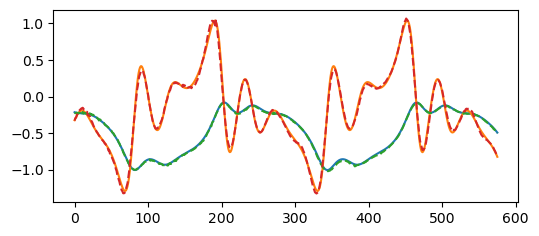

In [12]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [13]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.095279, valid=0.032770, test=0.033224
	validation loss decreased (inf -> 0.032770), saving model ...
	epoch 2 losses: train=0.029545, valid=0.028819, test=0.029256
	validation loss decreased (0.032770 -> 0.028819), saving model ...
	epoch 3 losses: train=0.028708, valid=0.028299, test=0.028756
	validation loss decreased (0.028819 -> 0.028299), saving model ...
	epoch 4 losses: train=0.028233, valid=0.028100, test=0.028443
	validation loss decreased (0.028299 -> 0.028100), saving model ...
	epoch 5 losses: train=0.027851, valid=0.027597, test=0.027976
	validation loss decreased (0.028100 -> 0.027597), saving model ...
	epoch 6 losses: train=0.027192, valid=0.026468, test=0.026901
	validation loss decreased (0.027597 -> 0.026468), saving model ...
	epoch 7 losses: train=0.025799, valid=0.025077, test=0.025565
	validation loss decreased (0.026468 -> 0.025077), saving model ...
	epoch 8 losses: train=0.024900, valid=0.024435, 

In [14]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

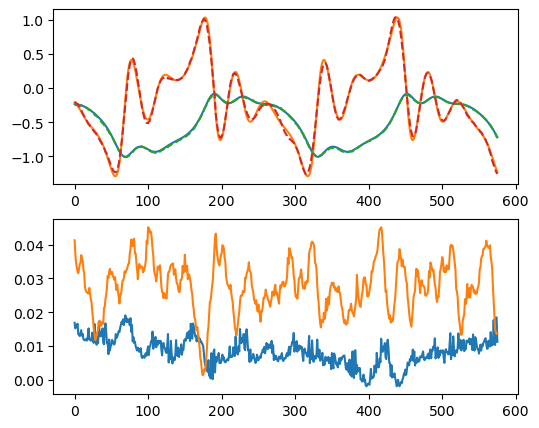

In [15]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

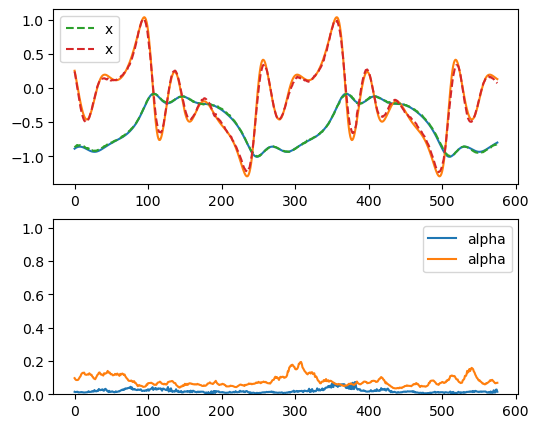

In [16]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        pre = model_output[0]
        alpha = model_output[9]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break